# Generación de modelos

## 1. Configuración del entorno

Se inicializa el entorno de trabajo importando el paquete `geoai` y definiendo las rutas hacia los datos de entrenamiento procesados (teselas de imágenes y máscaras) y el directorio donde se almacenarán los modelos resultantes.

In [ ]:
import geoai

# Configurar rutas relativas
MODELS_DATA_PATH = "../data/geoai/models"
TRAIN_IMAGES_PATH = "../data/train/output/images"
TRAIN_MASKS_PATH = "../data/train/output/masks"
TEST_PATH = "../data/test"

## 2. Generación de modelos

Se inicia el primer experimento de entrenamiento utilizando una arquitectura **U-Net** con un *encoder* **ResNet-34**. Esta red es conocida por su profundidad y conexiones residuales, lo que facilita el aprendizaje de características complejas. Se utilizan pesos preentrenados en ImageNet. El entrenamiento se configura para 50 épocas con un tamaño de lote (*batch size*) de 8, monitoreando métricas como IoU (intersección sobre unión) para evaluar el progreso.

In [ ]:
# Adaptar el modelo U-Net con codificación ResNet
geoai.train_segmentation_model(
    images_dir=TRAIN_IMAGES_PATH,
    labels_dir=TRAIN_MASKS_PATH,
    output_dir=f"{MODELS_DATA_PATH}/unet_resnet",
    architecture="unet",
    encoder_name="resnet34",
    encoder_weights="imagenet",
    num_channels=3,
    num_classes=2,
    batch_size=8,
    num_epochs=50,
    learning_rate=0.001,
    val_split=0.2,
    verbose=False,
)

Using device: cuda
Found 323 image files and 323 label files
Training on 258 images, validating on 65 images
Checking image sizes for compatibility...
All sampled images have the same size: (512, 512)
No resizing needed.
Testing data loader...
Data loader test passed.


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Starting training with unet + resnet34
Model parameters: 24,436,514
Epoch 1/50: Train Loss: 0.1885, Val Loss: 0.1282, Val IoU: 0.6194, Val F1: 0.7038, Val Precision: 0.8808, Val Recall: 0.6622
Saving best model with IoU: 0.6194
Epoch 2/50: Train Loss: 0.1088, Val Loss: 0.1750, Val IoU: 0.5885, Val F1: 0.6575, Val Precision: 0.9083, Val Recall: 0.6242
Epoch 3/50: Train Loss: 0.1020, Val Loss: 0.0952, Val IoU: 0.7183, Val F1: 0.8012, Val Precision: 0.8685, Val Recall: 0.7795
Saving best model with IoU: 0.7183
Epoch 4/50: Train Loss: 0.0882, Val Loss: 0.1405, Val IoU: 0.5838, Val F1: 0.6521, Val Precision: 0.9170, Val Recall: 0.6191
Epoch 5/50: Train Loss: 0.0844, Val Loss: 0.0952, Val IoU: 0.7181, Val F1: 0.7984, Val Precision: 0.8477, Val Recall: 0.7963
Epoch 6/50: Train Loss: 0.0869, Val Loss: 0.0903, Val IoU: 0.7236, Val F1: 0.8048, Val Precision: 0.8473, Val Recall: 0.8104
Saving best model with IoU: 0.7236
Epoch 7/50: Train Loss: 0.0882, Val Loss: 0.0850, Val IoU: 0.7557, Val F1: 0.

Se procede con el segundo experimento, esta vez empleando un *encoder* **MobileNetV2**. Esta arquitectura está optimizada para la eficiencia computacional, con un número significativamente menor de parámetros que ResNet. El objetivo es evaluar si un modelo más ligero puede ofrecer un rendimiento comparable con un menor coste de recursos, lo cual es relevante para despliegues en entornos con hardware limitado.

In [ ]:
# Adaptar el modelo U-Net con codificación MobileNet
geoai.train_segmentation_model(
    images_dir=TRAIN_IMAGES_PATH,
    labels_dir=TRAIN_MASKS_PATH,
    output_dir=f"{MODELS_DATA_PATH}/unet_mobilenet",
    architecture="unet",
    encoder_name="mobilenet_v2",
    encoder_weights="imagenet",
    num_channels=3,
    num_classes=2,
    batch_size=8,
    num_epochs=50,
    learning_rate=0.001,
    val_split=0.2,
    verbose=False,
)

Using device: cuda
Found 323 image files and 323 label files
Training on 258 images, validating on 65 images
Checking image sizes for compatibility...
All sampled images have the same size: (512, 512)
No resizing needed.
Testing data loader...
Data loader test passed.


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/14.2M [00:00<?, ?B/s]

Starting training with unet + mobilenet_v2
Model parameters: 6,629,090
Epoch 1/50: Train Loss: 0.3869, Val Loss: 0.2490, Val IoU: 0.4756, Val F1: 0.5008, Val Precision: 0.8538, Val Recall: 0.5099
Saving best model with IoU: 0.4756
Epoch 2/50: Train Loss: 0.1519, Val Loss: 0.1294, Val IoU: 0.6830, Val F1: 0.7745, Val Precision: 0.7729, Val Recall: 0.8240
Saving best model with IoU: 0.6830
Epoch 3/50: Train Loss: 0.1199, Val Loss: 0.1061, Val IoU: 0.6690, Val F1: 0.7562, Val Precision: 0.8928, Val Recall: 0.7125
Epoch 4/50: Train Loss: 0.0961, Val Loss: 0.0866, Val IoU: 0.7466, Val F1: 0.8269, Val Precision: 0.8816, Val Recall: 0.8143
Saving best model with IoU: 0.7466
Epoch 5/50: Train Loss: 0.0934, Val Loss: 0.1279, Val IoU: 0.5822, Val F1: 0.6488, Val Precision: 0.8836, Val Recall: 0.6145
Epoch 6/50: Train Loss: 0.1018, Val Loss: 0.0955, Val IoU: 0.7474, Val F1: 0.8281, Val Precision: 0.8248, Val Recall: 0.8626
Saving best model with IoU: 0.7474
Epoch 7/50: Train Loss: 0.0889, Val Los

Finalmente, se entrena un tercer modelo utilizando **EfficientNet-B1** como *encoder*. Esta familia de modelos utiliza un método de escalado compuesto que equilibra la profundidad, anchura y resolución de la red, ofreciendo teóricamente una mejor relación precisión-eficiencia. Idealmente, esto modelo debe capturar detalles más finos de las estructuras dañadas.

In [ ]:
# Adaptar el modelo U-Net con codificación EfficientNet
geoai.train_segmentation_model(
    images_dir=TRAIN_IMAGES_PATH,
    labels_dir=TRAIN_MASKS_PATH,
    output_dir=f"{MODELS_DATA_PATH}/unet_efficientnet",
    architecture="unet",
    encoder_name="efficientnet-b1",
    encoder_weights="imagenet",
    num_channels=3,
    num_classes=2,
    batch_size=8,
    num_epochs=50,
    learning_rate=0.001,
    val_split=0.2,
    verbose=False,
)

Using device: cuda
Found 323 image files and 323 label files
Training on 258 images, validating on 65 images
Checking image sizes for compatibility...
All sampled images have the same size: (512, 512)
No resizing needed.
Testing data loader...
Data loader test passed.


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/31.5M [00:00<?, ?B/s]

Starting training with unet + efficientnet-b1
Model parameters: 8,757,250
Epoch 1/50: Train Loss: 0.4134, Val Loss: 0.1834, Val IoU: 0.6808, Val F1: 0.7699, Val Precision: 0.8126, Val Recall: 0.7770
Saving best model with IoU: 0.6808
Epoch 2/50: Train Loss: 0.1204, Val Loss: 0.1598, Val IoU: 0.5685, Val F1: 0.6380, Val Precision: 0.8245, Val Recall: 0.6085
Epoch 3/50: Train Loss: 0.0931, Val Loss: 0.1769, Val IoU: 0.5242, Val F1: 0.5752, Val Precision: 0.7937, Val Recall: 0.5586
Epoch 4/50: Train Loss: 0.0832, Val Loss: 0.1979, Val IoU: 0.4971, Val F1: 0.5363, Val Precision: 0.7655, Val Recall: 0.5310
Epoch 5/50: Train Loss: 0.0755, Val Loss: 0.2758, Val IoU: 0.4745, Val F1: 0.4983, Val Precision: 0.7840, Val Recall: 0.5087
Epoch 6/50: Train Loss: 0.0705, Val Loss: 0.2699, Val IoU: 0.4746, Val F1: 0.4987, Val Precision: 0.7470, Val Recall: 0.5088
Epoch 7/50: Train Loss: 0.0689, Val Loss: 0.2540, Val IoU: 0.4747, Val F1: 0.4990, Val Precision: 0.7860, Val Recall: 0.5091
Epoch 8/50: Trai

## 3. Análisis de rendimiento

Tras completar el entrenamiento, se visualizan las curvas de aprendizaje del modelo ResNet-34. Se grafican la pérdida (*loss*) de entrenamiento y validación, así como la evolución de las métricas de precisión, IoU, F1-score y Recall a lo largo de las épocas. Esto permite diagnosticar posibles problemas de sobreajuste (*overfitting*) o subajuste (*underfitting*).

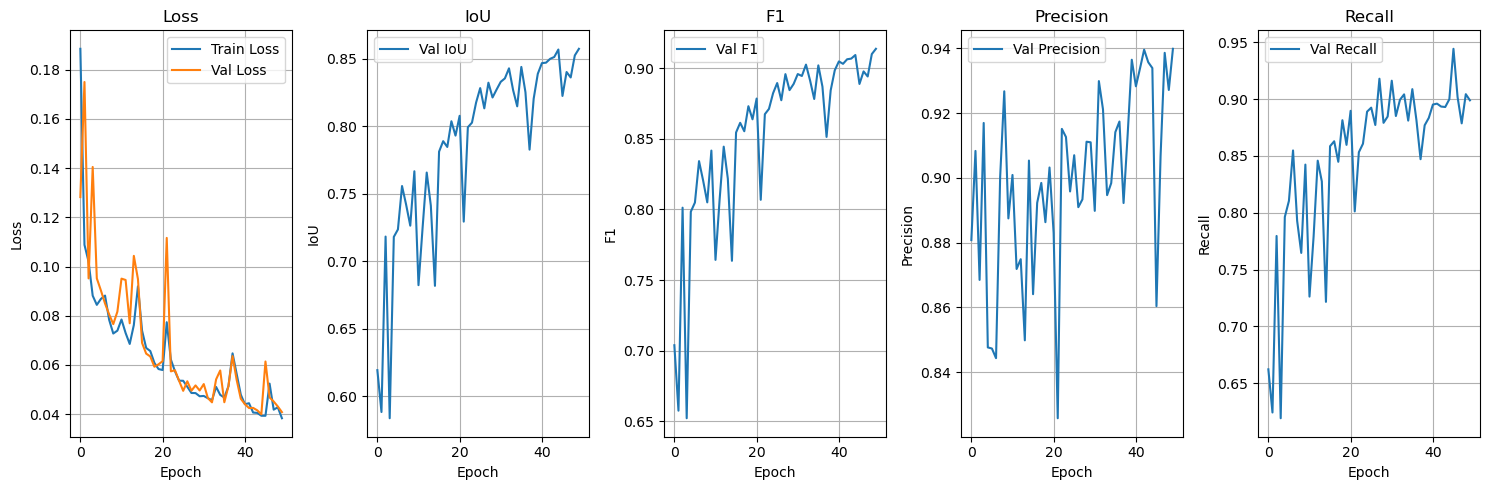


=== Performance Metrics Summary ===
IoU     - Best: 0.8573 | Final: 0.8573
F1      - Best: 0.9137 | Final: 0.9137
Precision - Best: 0.9398 | Final: 0.9398
Recall  - Best: 0.9443 | Final: 0.8989
Val Loss - Best: 0.0400 | Final: 0.0408



,epoch,train_loss,val_loss,val_iou,val_f1,val_precision,val_recall
0,1,0.188515,0.128246,0.619446,0.703834,0.880811,0.662170
1,2,0.108844,0.175022,0.588459,0.657504,0.908326,0.624168
2,3,0.101996,0.095190,0.718304,0.801213,0.868514,0.779547
3,4,0.088174,0.140489,0.583847,0.652141,0.916954,0.619109
4,5,0.084438,0.095208,0.718076,0.798358,0.847678,0.796269
5,6,0.086865,0.090277,0.723583,0.804835,0.847343,0.810445
6,7,0.088205,0.084985,0.755707,0.834155,0.844363,0.854828
7,8,0.078375,0.080576,0.741828,0.820326,0.900276,0.792839
8,9,0.072793,0.076608,0.726380,0.804974,0.926729,0.764635
9,10,0.073953,0.081671,0.766640,0.841629,0.887498,0.842359


In [ ]:
# Evaluar el modelo U-Net con codificación ResNet
RESNET_PATH = f"{MODELS_DATA_PATH}/unet_resnet"

geoai.plot_performance_metrics(
    history_path=f"{RESNET_PATH}/training_history.pth", figsize=(15, 5), verbose=True
)

Se analizan las métricas de rendimiento del modelo basado en MobileNetV2, comparando sus curvas de convergencia y puntuaciones finales con las obtenidas por el modelo anterior.

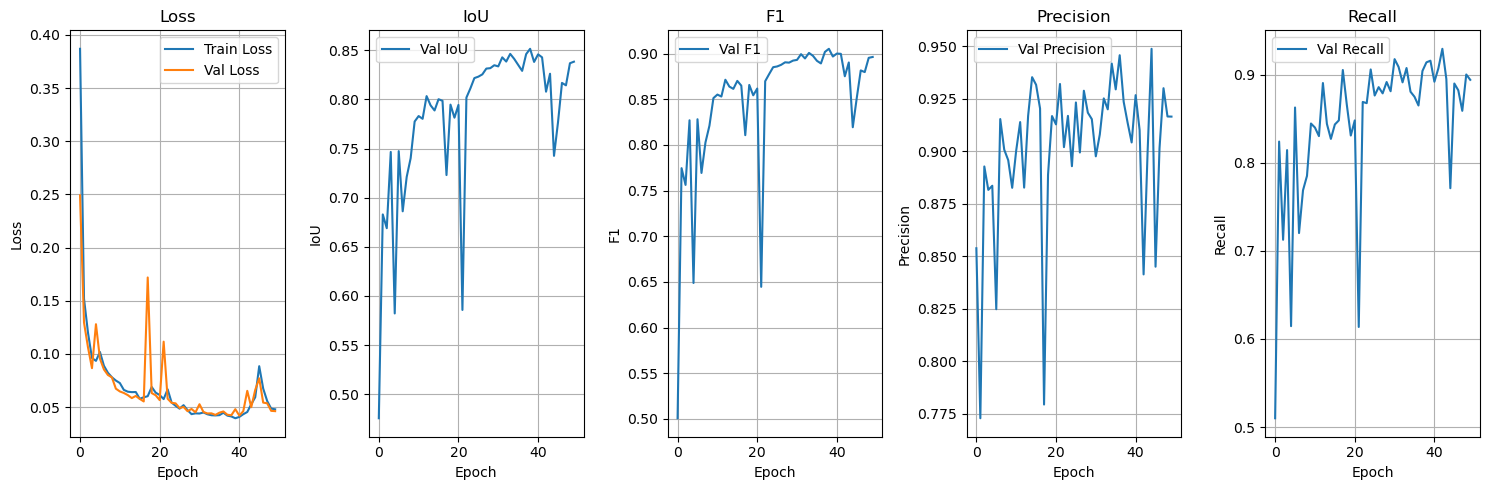


=== Performance Metrics Summary ===
IoU     - Best: 0.8515 | Final: 0.8384
F1      - Best: 0.9052 | Final: 0.8962
Precision - Best: 0.9488 | Final: 0.9165
Recall  - Best: 0.9293 | Final: 0.8941
Val Loss - Best: 0.0420 | Final: 0.0462



,epoch,train_loss,val_loss,val_iou,val_f1,val_precision,val_recall
0,1,0.386862,0.249050,0.475582,0.500819,0.853841,0.509935
1,2,0.151896,0.129444,0.682987,0.774528,0.772901,0.823973
2,3,0.119920,0.106119,0.669005,0.756201,0.892785,0.712517
3,4,0.096086,0.086592,0.746596,0.826944,0.881633,0.814292
4,5,0.093448,0.127923,0.582239,0.648829,0.883609,0.614471
5,6,0.101806,0.095492,0.747402,0.828069,0.824811,0.862647
6,7,0.088862,0.085381,0.686178,0.769298,0.915356,0.720115
7,8,0.082272,0.080169,0.721130,0.802636,0.900777,0.768667
8,9,0.078065,0.077923,0.740258,0.821033,0.895785,0.785051
9,10,0.074945,0.067304,0.777560,0.851189,0.882624,0.844481


In [ ]:
# Evaluar el modelo U-Net con codificación MobileNet
MOBILENET_PATH = f"{MODELS_DATA_PATH}/unet_mobilenet"

geoai.plot_performance_metrics(
    history_path=f"{MOBILENET_PATH}/training_history.pth", figsize=(15, 5), verbose=True
)

Por último, se examinan los resultados del modelo EfficientNet-B1. Las métricas obtenidas (IoU, F1, Precision, Recall) se comparan con los otros dos modelos para seleccionar la arquitectura óptima que se utilizará en la fase de inferencia final sobre las imágenes completas del desastre (cuaderno `03_extraccion_huellas.ipynb`).

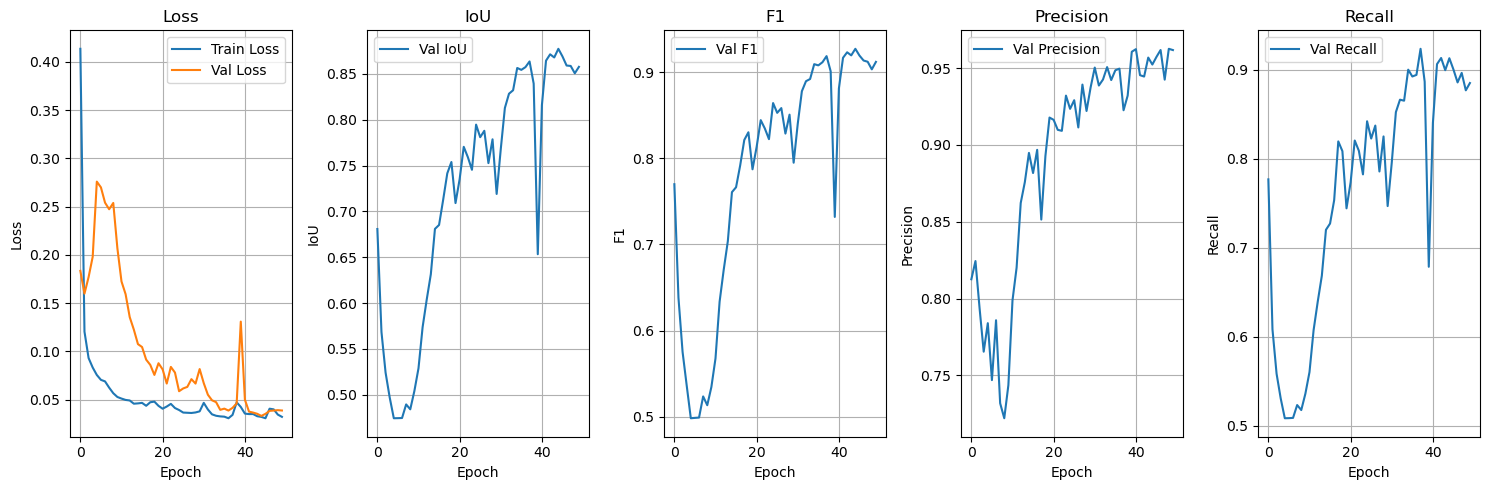


=== Performance Metrics Summary ===
IoU     - Best: 0.8773 | Final: 0.8576
F1      - Best: 0.9271 | Final: 0.9119
Precision - Best: 0.9626 | Final: 0.9618
Recall  - Best: 0.9236 | Final: 0.8852
Val Loss - Best: 0.0331 | Final: 0.0387



,epoch,train_loss,val_loss,val_iou,val_f1,val_precision,val_recall
0,1,0.413421,0.183387,0.680794,0.769923,0.812625,0.776968
1,2,0.120449,0.159775,0.568525,0.638027,0.824457,0.608549
2,3,0.093072,0.176889,0.524198,0.575205,0.793738,0.558615
3,4,0.083239,0.197932,0.497145,0.536322,0.765491,0.530963
4,5,0.075546,0.275832,0.474472,0.498279,0.784036,0.508659
5,6,0.070486,0.269874,0.474575,0.498708,0.746996,0.508787
6,7,0.068875,0.254010,0.474736,0.499048,0.785950,0.509061
7,8,0.062409,0.247222,0.489554,0.523605,0.731927,0.523481
8,9,0.056636,0.253734,0.484212,0.513405,0.722175,0.517864
9,10,0.052735,0.206873,0.504170,0.534541,0.743720,0.536215


In [ ]:
# Evaluar el modelo U-Net con codificación EfficientNet
EFFICIENTNET_PATH = f"{MODELS_DATA_PATH}/unet_efficientnet"

geoai.plot_performance_metrics(
    history_path=f"{EFFICIENTNET_PATH}/training_history.pth",
    figsize=(15, 5),
    verbose=True,
)

## 4. Inferencia de prueba

Para verificar cualitativamente el funcionamiento del modelo ResNet-34 antes de aplicarlo a gran escala, se realiza una prueba de inferencia sobre una pequeña muestra de datos (`test_2021.tif`). Se genera una predicción de segmentación y se convierte inmediatamente a formato vectorial (GeoJSON) para facilitar su inspección.

In [ ]:
# Predecir con ResNet
PREDICTION_PATH = f"{TEST_PATH}/output/test_2021_resnet.tif"

geoai.semantic_segmentation(
    input_path=f"{TEST_PATH}/images/test_2021.tif",
    output_path=PREDICTION_PATH,
    model_path=f"{RESNET_PATH}/best_model.pth",
    architecture="unet",
    encoder_name="resnet34",
    num_channels=3,
    num_classes=2,
    window_size=512,  # Tamaño de ventana deslizante
    overlap=256,  # Solapamiento para suavizar bordes
    batch_size=8,
)

# Vectorizar la imagen
RESNET_OUTPUT_PATH = f"{TEST_PATH}/output/test_2021_resnet.geojson"
geoai.orthogonalize(PREDICTION_PATH, RESNET_OUTPUT_PATH, epsilon=2)

Input file format: GeoTIFF (.tif)
Processing 176 windows...


204it [00:02, 68.57it/s]                                                                            


Predicted classes: 2 classes, Background: 96.7%
Inference completed in 3.87 seconds
Saved prediction to ../data/test/output/test_2021_resnet.tif
Processing 229 features...


Converting features: 100%|████████████████████████████████████| 229/229 [00:01<00:00, 183.35shape/s]

Saving to ../data/test/output/test_2021_resnet.geojson...
Done!


,geometry,value
0,"POLYGON ((216430.2 3169184.2, 216430.8 3169184...",1
1,"POLYGON ((216462.6 3169177.2, 216462.6 3169177...",1
2,"POLYGON ((216501.7 3169176.3, 216489.1 3169176...",1
3,"POLYGON ((216479.36 3169179.02, 216478.503 316...",1
4,"POLYGON ((216237.6 3169173.6, 216238.4 3169173...",1
...,...,...
215,"POLYGON ((216663.261 3168650.102, 216656.258 3...",1
216,"POLYGON ((216462.7 3168648, 216462.7 3168637.3...",1
217,"POLYGON ((216971.094 3168640.076, 216969.565 3...",1
218,"POLYGON ((216807.9 3168631.1, 216807.9 3168618...",1


Se repite el proceso de inferencia de prueba, esta vez utilizando el modelo entrenado con MobileNetV2. Esto permite comparar visualmente las diferencias en la detección de bordes y falsos positivos entre ambas arquitecturas.

In [ ]:
# Predecir con MobileNet
PREDICTION_PATH = f"{TEST_PATH}/output/test_2021_mobilenet.tif"

geoai.semantic_segmentation(
    input_path=f"{TEST_PATH}/images/test_2021.tif",
    output_path=PREDICTION_PATH,
    model_path=f"{MOBILENET_PATH}/best_model.pth",
    architecture="unet",
    encoder_name="mobilenet_v2",
    num_channels=3,
    num_classes=2,
    window_size=512,  # Tamaño de ventana deslizante
    overlap=256,  # Solapamiento para suavizar bordes
    batch_size=8,
)

# Vectorizar la imagen
MOBILENET_OUTPUT_PATH = f"{TEST_PATH}/output/test_2021_mobilenet.geojson"
geoai.orthogonalize(PREDICTION_PATH, MOBILENET_OUTPUT_PATH, epsilon=2)

Input file format: GeoTIFF (.tif)
Processing 176 windows...


204it [00:02, 70.45it/s]                                                                            


Predicted classes: 2 classes, Background: 95.8%
Inference completed in 3.77 seconds
Saved prediction to ../data/test/output/test_2021_mobilenet.tif
Processing 298 features...


Converting features: 100%|████████████████████████████████████| 298/298 [00:01<00:00, 206.49shape/s]

Saving to ../data/test/output/test_2021_mobilenet.geojson...
Done!


,geometry,value
0,"POLYGON ((216484.2 3169179.4, 216484.4 3169179...",1
1,"POLYGON ((216451 3169180.3, 216453.4 3169180.3...",1
2,"POLYGON ((216479.262 3169178.873, 216478.33 31...",1
3,"POLYGON ((216494.6 3169183, 216495.2 3169183, ...",1
4,"POLYGON ((216501.8 3169170.4, 216501.8 3169170...",1
...,...,...
260,"POLYGON ((216584.4 3168627, 216585.8 3168627, ...",1
261,"POLYGON ((216806.788 3168617.053, 216797 31686...",1
262,"POLYGON ((216662 3168622.6, 216662.2 3168622.6...",1
263,"POLYGON ((216689.6 3168618.4, 216690.2 3168618...",1


Asimismo, se ejecuta la inferencia de prueba con el modelo EfficientNet-B1. Al tener predicciones de los tres modelos sobre la misma imagen de prueba, se puede realizar una comparación directa y justa de su capacidad de generalización.

In [ ]:
# Predecir con EfficientNet
PREDICTION_PATH = f"{TEST_PATH}/output/test_2021_efficientnet.tif"

geoai.semantic_segmentation(
    input_path=f"{TEST_PATH}/images/test_2021.tif",
    output_path=PREDICTION_PATH,
    model_path=f"{EFFICIENTNET_PATH}/best_model.pth",
    architecture="unet",
    encoder_name="efficientnet-b1",
    num_channels=3,
    num_classes=2,
    window_size=512,  # Tamaño de ventana deslizante
    overlap=256,  # Solapamiento para suavizar bordes
    batch_size=8,
)

# Vectorizar la imagen
EFFICIENTNET_OUTPUT_PATH = f"{TEST_PATH}/output/test_2021_efficientnet.geojson"
geoai.orthogonalize(PREDICTION_PATH, EFFICIENTNET_OUTPUT_PATH, epsilon=2)

Input file format: GeoTIFF (.tif)
Processing 176 windows...


204it [00:04, 47.85it/s]                                                                            


Predicted classes: 2 classes, Background: 96.6%
Inference completed in 5.14 seconds
Saved prediction to ../data/test/output/test_2021_efficientnet.tif
Processing 307 features...


Converting features: 100%|████████████████████████████████████| 307/307 [00:01<00:00, 231.24shape/s]


Saving to ../data/test/output/test_2021_efficientnet.geojson...
Done!


,geometry,value
0,"POLYGON ((216447 3169182.8, 216447.2 3169182.8...",1
1,"POLYGON ((216504.002 3169178.186, 216488.644 3...",1
2,"POLYGON ((216469.084 3169180.588, 216479.64 31...",1
3,"POLYGON ((216240.4 3169171.6, 216240.6 3169171...",1
4,"POLYGON ((216239.9 3169173.6, 216239.9 3169169...",1
...,...,...
275,"POLYGON ((216462.7 3168647.9, 216462.7 3168637...",1
276,"POLYGON ((216969.6 3168640.4, 216968.312 31686...",1
277,"POLYGON ((216808.5 3168631.022, 216808.5 31686...",1
278,"POLYGON ((216891 3168614.8, 216891.6 3168614.8...",1


## 5. Revisión de resultados

Se despliega un mapa interactivo dividido para comparar las predicciones de ResNet-34 (naranja) y MobileNetV2 (rojo). Esta visualización lado a lado permite identificar rápidamente qué modelo define mejor los contornos de los edificios y cuál es más propenso a cometer errores en zonas ambiguas.

In [ ]:
import ipywidgets as w
import leafmap.leafmap as leafmap

EFFICIENTNET_OUTPUT_PATH = f"{TEST_PATH}/output/test_2021_efficientnet.geojson"
RESNET_OUTPUT_PATH = f"{TEST_PATH}/output/test_2021_resnet.geojson"
MOBILENET_OUTPUT_PATH = f"{TEST_PATH}/output/test_2021_mobilenet.geojson"


# Añadir propiedades geométricas
resnet_props = geoai.add_geometric_properties(
    RESNET_OUTPUT_PATH, area_unit="m2", length_unit="m"
)
mobilenet_props = geoai.add_geometric_properties(
    MOBILENET_OUTPUT_PATH, area_unit="m2", length_unit="m"
)

data = [
    (mobilenet_props, "red", "Modelo: U-Net + MobileNetV2"),
    (resnet_props, "orange", "Modelo: U-Net + ResNet-34"),
]

maps = [
    leafmap.Map(
        center=[28.6162, -17.8986],
        zoom=16,
        min_zoom=15,
        max_zoom=20,
        toolbar_control=False,
        draw_control=False,
        fullscreen_control=False,
        layers_control=True,
    )
    for i in range(2)
]

for m, (geojson, color, model_name) in zip(maps, data):
    m.clear_layers()

    m.add_wms_layer(
        url="https://idecan1.grafcan.es/ServicioWMS/Historico/Ortofotos/OrtoExpress_2021?",
        layers="WMS_OrtoExpress",
        name="IDECanarias OrtoExpress 2021 (20 cm/pixel)",
        attribution='<a href="https://www.grafcan.es/aviso-legal/" target="_blank">GRAFCAN</a>, Ortofotos Express de Canarias',
        format="image/jpeg",
        max_zoom=20,
        base=True,
    )

    m.add_gdf(
        geojson,
        layer_name=model_name,
        style={"color": color, "fillOpacity": 0.25, "weight": 2},
        zoom_to_layer=True,
    )

w.jslink((maps[0], "center"), (maps[1], "center"))
w.jslink((maps[0], "zoom"), (maps[1], "zoom"))

maps[0].layout.width = maps[1].layout.width = "50%"
display(w.HBox(maps, layout=w.Layout(height="600px")))

Finalmente, se comparan visualmente el modelo EfficientNet-B1 (verde) con el MobileNetV2 (red). Esta última comparación permite observar si la mayor complejidad de EfficientNet se traduce en una mejora en la calidad de la segmentación.

In [ ]:
import ipywidgets as w
import leafmap.leafmap as leafmap

# Añadir propiedades geométricas
efficientnet_props = geoai.add_geometric_properties(
    EFFICIENTNET_OUTPUT_PATH, area_unit="m2", length_unit="m"
)
mobilenet_props = geoai.add_geometric_properties(
    MOBILENET_OUTPUT_PATH, area_unit="m2", length_unit="m"
)

data = [
    (efficientnet_props, "green", "Modelo: U-Net + EfficientNet B1"),
    (mobilenet_props, "red", "Modelo: U-Net + MobileNetV2"),
]

maps = [
    leafmap.Map(
        center=[28.6162, -17.8986],
        zoom=16,
        min_zoom=15,
        max_zoom=20,
        toolbar_control=False,
        draw_control=False,
        fullscreen_control=False,
        layers_control=True,
    )
    for i in range(2)
]

for m, (geojson, color, model_name) in zip(maps, data):
    m.clear_layers()

    m.add_wms_layer(
        url="https://idecan1.grafcan.es/ServicioWMS/Historico/Ortofotos/OrtoExpress_2021?",
        layers="WMS_OrtoExpress",
        name="IDECanarias OrtoExpress 2021 (20 cm/pixel)",
        attribution='<a href="https://www.grafcan.es/aviso-legal/" target="_blank">GRAFCAN</a>, Ortofotos Express de Canarias',
        format="image/jpeg",
        max_zoom=20,
        base=True,
    )

    m.add_gdf(
        geojson,
        layer_name=model_name,
        style={"color": color, "fillOpacity": 0.25, "weight": 2},
        zoom_to_layer=True,
    )

w.jslink((maps[0], "center"), (maps[1], "center"))
w.jslink((maps[0], "zoom"), (maps[1], "zoom"))

maps[0].layout.width = maps[1].layout.width = "50%"
display(w.HBox(maps, layout=w.Layout(height="600px")))